# 2026 Remaining Season — Lap Time & Qualifying Cutoff Predictions

**Every round from Baku (round 14) through the Abu Dhabi finale (round 23)**, predicting pole time and the Q1/Q2 qualifying cutoffs under F1's 2026 regulation reset — using only real, sourced qualifying data. No synthetic numbers anywhere in this notebook.

**Method:** measure the real 2026-vs-2025 pace delta at circuits that have run under both rule sets, then apply it to each remaining circuit's own real recent-history baseline, with an honest confidence label and (where relevant) a qualitative layout adjustment per circuit.

In [1]:
import sys
sys.path.insert(0, '../src')
sys.path.insert(0, '../data/raw')
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (11, 5)

import real_qualifying_data as data
from features.delta_model import clean_delta_stats, all_delta_stats
from features.quali_gap_model import compute_gap_percentages
from models.season_predictor import predict_remaining_season, format_time

## 1. The 2026 regulation pace delta

Measured at four weather-matched circuits that ran under both 2025 and 2026 rules.

In [2]:
clean = clean_delta_stats()
for c, v in clean['per_circuit'].items():
    print(f'{c:28s} {v:+.3f}s')
print(f"\nMean: {clean['mean']:.3f}s   Std dev: {clean['stdev']:.3f}s   n={clean['n']}")

Canada (Montreal)            +1.679s
Miami                        +1.594s
China (Shanghai)             +1.423s
Japan (Suzuka)               +1.795s

Mean: 1.623s   Std dev: 0.157s   n=4


## 2. Q1/Q2 cutoff gap, as a percentage of pole

Derived from every real full qualifying grid available (2025 China, 2026 Australia, 2026 China) — gap-to-pole scales with lap time, so a percentage generalizes across circuits better than a fixed-second gap.

In [3]:
gaps = compute_gap_percentages()
for row in gaps['rows']:
    print(f"{row['source']:28s} Q1: {row['q1_gap_pct']*100:.2f}%   Q2: {row['q2_gap_pct']*100:.2f}%")
print(f"\nAveraged: Q1 {gaps['avg_q1_gap_pct']*100:.2f}%,  Q2 {gaps['avg_q2_gap_pct']*100:.2f}%")

2025 China                   Q1: 1.41%   Q2: 1.05%
2026 Australia               Q1: 3.48%   Q2: 2.17%
2026 China (partial grid)    Q1: 2.25%   Q2: 1.40%

Averaged: Q1 2.38%,  Q2 1.54%


## 3. Predictions: every remaining round

In [4]:
predictions = predict_remaining_season()
for p in predictions:
    print(f"Rd{p['round']:>3}  {p['circuit']:<32} {p['date']}  pole {format_time(p['predicted_pole_s'])}  Q2 {format_time(p['predicted_q2_cutoff_s'])}  Q1 {format_time(p['predicted_q1_cutoff_s'])}  [{p['confidence']}]")

Rd 14  Azerbaijan (Baku)                2026-09-26  pole 1:42.298  Q2 1:43.874  Q1 1:44.734  [high]
Rd 16  Bahrain-in-Malaysia (Sepang)     2026-10-04  pole 1:31.699  Q2 1:33.111  Q1 1:33.882  [low]
Rd 17  Singapore (Marina Bay)           2026-10-11  pole 1:30.781  Q2 1:32.179  Q1 1:32.943  [medium]
Rd 18  United States (Austin, COTA)     2026-10-18  pole 1:34.810  Q2 1:36.271  Q1 1:37.068  [high]
Rd 19  Mexico City                      2026-10-25  pole 1:17.309  Q2 1:18.499  Q1 1:19.150  [medium]
Rd 20  Brazil (Interlagos)              2026-11-08  pole 1:11.134  Q2 1:12.229  Q1 1:12.828  [medium]
Rd 21  Las Vegas                        2026-11-21  pole 1:33.735  Q2 1:35.178  Q1 1:35.967  [medium]
Rd 22  Qatar (Lusail)                   2026-11-29  pole 1:22.869  Q2 1:24.146  Q1 1:24.843  [medium]
Rd 23  Abu Dhabi (Yas Marina)           2026-12-06  pole 1:24.372  Q2 1:25.671  Q1 1:26.381  [high]


## 4. Visualizing the predictions

Pole, Q2 cutoff, and Q1 cutoff for every round — color-coded by confidence.

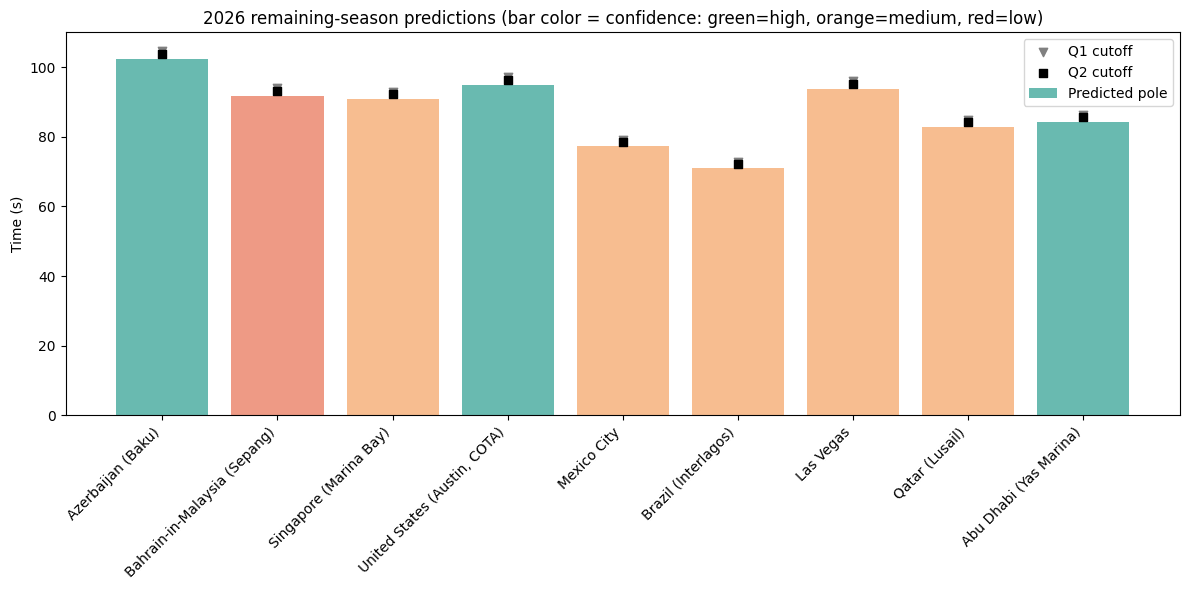

In [5]:
circuits = [p['circuit'] for p in predictions]
poles = [p['predicted_pole_s'] for p in predictions]
q2s = [p['predicted_q2_cutoff_s'] for p in predictions]
q1s = [p['predicted_q1_cutoff_s'] for p in predictions]
conf_colors = {'high': '#2a9d8f', 'medium': '#f4a261', 'low': '#e76f51'}
colors = [conf_colors[p['confidence']] for p in predictions]

import numpy as np
x = np.arange(len(circuits))
plt.figure(figsize=(12,6))
plt.scatter(x, q1s, marker='v', label='Q1 cutoff', color='gray', zorder=3)
plt.scatter(x, q2s, marker='s', label='Q2 cutoff', color='black', zorder=3)
plt.bar(x, poles, color=colors, alpha=0.7, label='Predicted pole', zorder=2)
plt.xticks(x, circuits, rotation=45, ha='right')
plt.ylabel('Time (s)')
plt.title('2026 remaining-season predictions (bar color = confidence: green=high, orange=medium, red=low)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Confidence varies enormously by circuit

Not every prediction deserves equal trust. Sepang (Bahrain-in-Malaysia) is the clear outlier: its only baseline is a 2017 pole time, meaning the model extrapolates across **two** full regulation eras (2017→2022 ground-effect, 2022→2026 this reset), not one.

In [6]:
for p in predictions:
    lo, hi = p['predicted_pole_range_s']
    width = hi - lo
    print(f"{p['circuit']:<32} range width: {width:.2f}s   [{p['confidence']}]")

Azerbaijan (Baku)                range width: 0.31s   [high]
Bahrain-in-Malaysia (Sepang)     range width: 5.31s   [low]
Singapore (Marina Bay)           range width: 1.11s   [medium]
United States (Austin, COTA)     range width: 0.31s   [high]
Mexico City                      range width: 1.11s   [medium]
Brazil (Interlagos)              range width: 1.11s   [medium]
Las Vegas                        range width: 1.11s   [medium]
Qatar (Lusail)                   range width: 1.11s   [medium]
Abu Dhabi (Yas Marina)           range width: 0.31s   [high]


## 6. Round-by-round detail, with full reasoning

In [7]:
for p in predictions:
    print(f"\n=== Round {p['round']}: {p['circuit']} ({p['date']}) ===")
    print(f"Baseline: {format_time(p['baseline_pole_s'])} (years used: {p['baseline_years']})")
    print(f"Predicted pole: {format_time(p['predicted_pole_s'])}")
    print(f"Q2 cutoff: {format_time(p['predicted_q2_cutoff_s'])}   Q1 cutoff: {format_time(p['predicted_q1_cutoff_s'])}")
    print(f"Confidence: {p['confidence']}")
    print(f"Notes: {p['notes']}")


=== Round 14: Azerbaijan (Baku) (2026-09-26) ===
Baseline: 1:40.976 (years used: [2022, 2023, 2024])
Predicted pole: 1:42.298
Q2 cutoff: 1:43.874   Q1 cutoff: 1:44.734
Confidence: high
Notes: 2025 pole (1:41.117) excluded from baseline: rain-affected Q3, six red flags. 2.2km pit straight — longest full-throttle stretch of any circuit bar Jeddah/Spa/Vegas, favoring 2026's low-drag active aero X-mode, hence the negative layout adjustment.

=== Round 16: Bahrain-in-Malaysia (Sepang) (2026-10-04) ===
Baseline: 1:30.076 (years used: [2017])
Predicted pole: 1:31.699
Q2 cutoff: 1:33.111   Q1 cutoff: 1:33.882
Confidence: low
Notes: Sepang has not hosted F1 since 2017 — a 9-year-old baseline from an entirely different car generation (2017's wide, high-downforce cars were among the fastest-cornering in history; 2022 ground-effect and now 2026 rules have both intervened since). The clean-circuit delta is being extrapolated across TWO regulation eras here, not one — treat this prediction as subst

## 7. Honest limitations

- **The clean delta (n=4) is applied uniformly** to circuits with very different characteristics — high-speed permanent tracks, street circuits, high altitude (Mexico), long-straight layouts (Baku, Vegas). The per-circuit layout adjustments are qualitative judgments, not fitted coefficients, because there's no 2026 data yet at any of these specific circuit types to calibrate against.
- **Sepang is a special case that deserves its own warning, not just a wider band**: extrapolating a 9-year-old, two-regulation-eras-removed baseline is fundamentally different from the other 8 predictions, which only extrapolate across one regulation change.
- **The Q1/Q2 gap percentages come from only 3 real grids**, two of which are actually the *same* circuit (China) one year apart — the averaged percentage is a reasonable starting point, not a robust circuit-independent constant.
- **Baseline year selection is a judgment call at circuits with only 1 clean year** (Singapore, Mexico, Brazil) — a different reasonable choice of which years to call 'clean' would shift those predictions by a few tenths.
- **None of this accounts for in-season car development.** If 2026 cars get faster relative to old-regulation pace as the season progresses (the usual pattern in a new-reg era), later rounds (Qatar, Abu Dhabi) could run faster than predicted here — the Monza data point in the companion delta analysis is inconclusive on this question, so no adjustment for it is applied.

**Bottom line:** treat the 'high confidence' rows (Baku, USA, Abu Dhabi) as reasonably solid estimates for a genuinely hard problem, and the 'low confidence' row (Sepang) as closer to an educated guess than a forecast.